# Global Resilience Index 
### World Bank Data Analysis | 100 Countries | 6 Domains | 2000–2023

This notebook analyzes how resilient countries are across six life-critical domains:
- **Digital Infrastructure** — internet and broadband access
- **Economic Fragility** — GDP growth and inflation
- **Food Security** — food imports dependency and undernourishment
- **Healthcare** — health expenditure, hospital beds, physicians
- **Political Stability** — World Bank governance score
- **Climate & Energy** — electricity access, renewables, CO2, energy consumption

Data sources: World Bank (15 indicators) + FAO Food Price Index


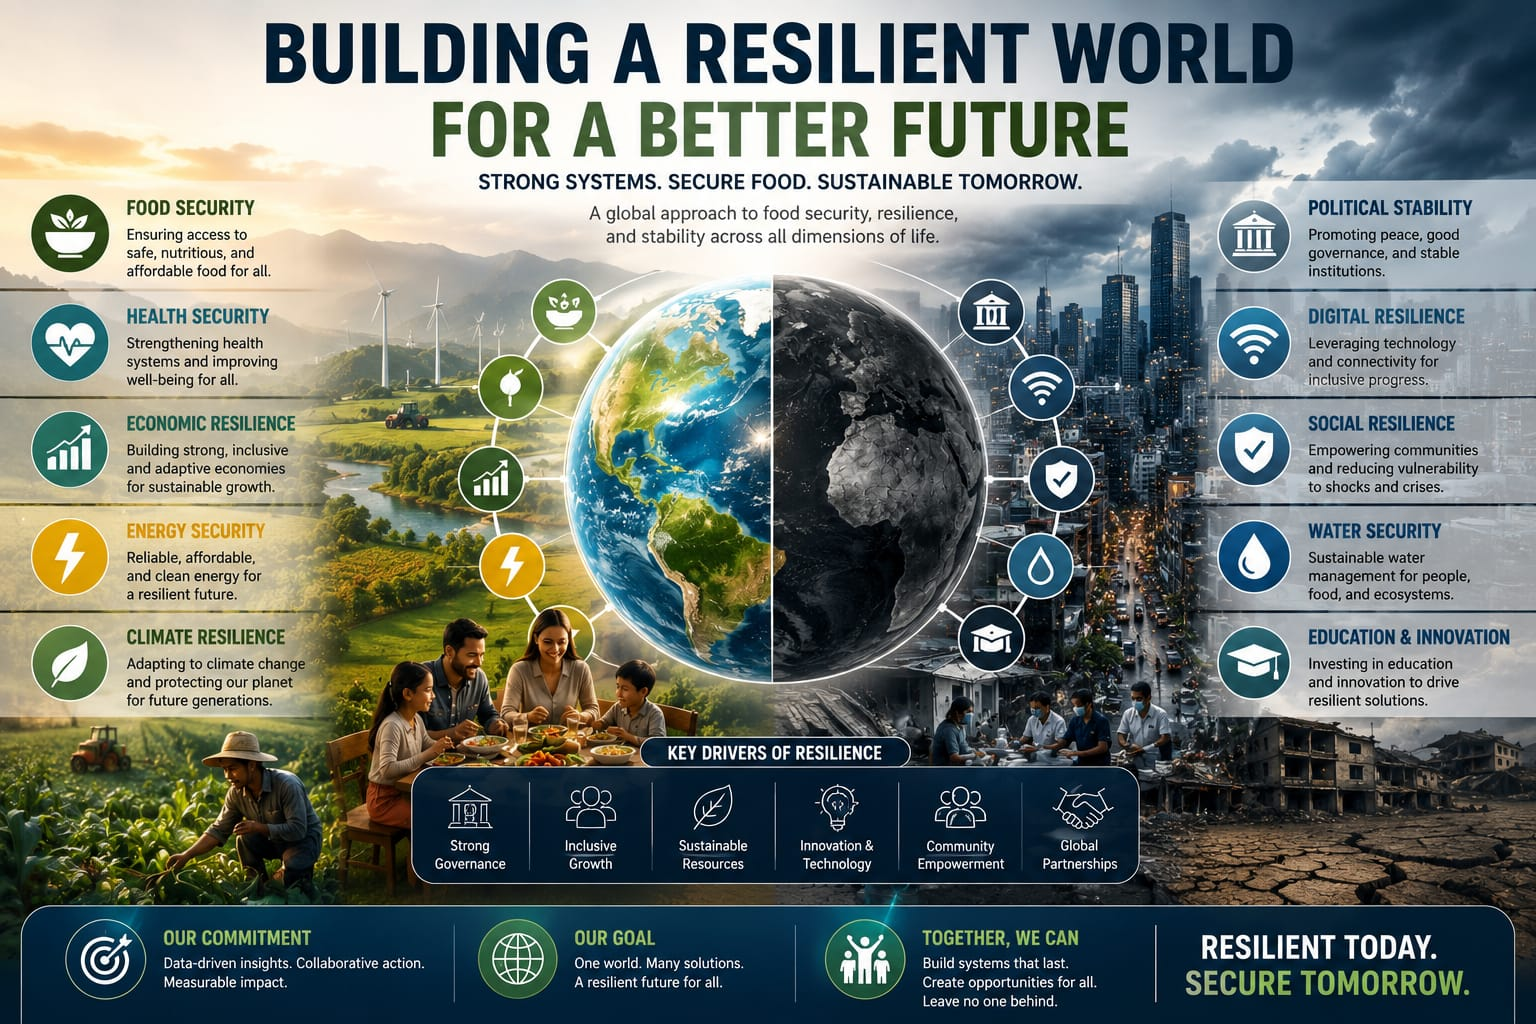

In [1]:
from IPython.display import Image, display

display(Image(filename=r"C:\Users\ASUS\Documents\Depi\final.jpeg"))

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"


## 1. Load Data

Setting up file paths for all 17 source files.


In [3]:
# ==============================================================================
# SECTION 1: FILE PATHS 
# ==============================================================================

path_fixed_broadband         = r"C:\Depi\Final_Data_EXCEL\Digital Infrastructure\Fixed broadband subscriptions.xlsx"
path_internet_users          = r"C:\Depi\Final_Data_EXCEL\Digital Infrastructure\Internet Users.xlsx"
path_gdp_growth              = r"C:\Depi\Final_Data_EXCEL\Economic Fragility\GDP Growth.xlsx"
path_inflation               = r"C:\Depi\Final_Data_EXCEL\Economic Fragility\Inflation.xlsx"
path_food_imports            = r"C:\Depi\Final_Data_EXCEL\Food\Food Imports % of merchandise imports.xlsx"
path_undernourishment        = r"C:\Depi\Final_Data_EXCEL\Food\Prevalence of Undernourishment.xlsx"
path_health_expenditure      = r"C:\Depi\Final_Data_EXCEL\Healthcare Capacity\Global Health Expenditure.xlsx"
path_hospitals               = r"C:\Depi\Final_Data_EXCEL\Healthcare Capacity\Hospitals.xlsx"
path_physicians              = r"C:\Depi\Final_Data_EXCEL\Healthcare Capacity\Physicians.xlsx"
path_political_stability     = r"C:\Depi\Final_Data_EXCEL\Political Stability\Political Stability.xlsx"
path_electricity_access      = r"C:\Depi\Final_Data_EXCEL\Climate & Energy\Access to electricity.xlsx"
path_clean_fuel              = r"C:\Depi\Final_Data_EXCEL\Climate & Energy\Clean Fuel Access.xlsx"
path_co2_emissions           = r"C:\Depi\Final_Data_EXCEL\Climate & Energy\CO2 emissions  .xlsx"
path_electricity_consumption = r"C:\Depi\Final_Data_EXCEL\Climate & Energy\Electricity consumption  .xlsx"
path_renewable_energy        = r"C:\Depi\Final_Data_EXCEL\Climate & Energy\Renewable energy  .xlsx"
path_fao_food_index          = r"C:\Depi\Final_Data_EXCEL\Food\FAO Food Price Index.xlsx"
path_government_debt         = r"C:\Depi\Final_Data_EXCEL\Economic Fragility\Government Debt.xlsx"
OUTPUT_DIR = r"C:\Depi\Deployment_Extracted\output"


## 2. Constants & Mappings

These constants define the 100 countries in the study, which indicators belong to which domain,
and which indicators need to be inverted (because higher = worse for resilience).


In [4]:
# The 100 countries included in this study
COUNTRY_CODES = {
    'GEO','MDA','ESP','CHE','GBR','HUN','MYS','RUS','CAN','ISL','NZL','TUR','KOR','MUS','THA',
    'JOR','KAZ','BLR','PHL','KGZ','AUS','BWA','COL','ARM','USA','CHL','LKA','MEX','IND','TUN',
    'AZE','BIH','UKR','CRI','ALB','ARE','URY','JAM','BRA','SLV','NOR','PER','AUT','BEL','CHN',
    'DEU','ISR','LVA','CZE','EST','FRA','IRL','ITA','MLT','NLD','PRT','PAK','IDN','FIN','LTU',
    'ROU','SVK','SVN','SWE','MNG','HRV','PAN','DNK','ECU','GRC','OMN','POL','SGP','BGD','BHR',
    'CYP','MAR','MKD','EGY','LUX','MOZ','BOL','KWT','ZMB','SAU','NPL','BFA','NIC','VNM','GTM',
    'KHM','RWA','PRY','TJK','TGO','ETH','SWZ','GHA','NAM','MDG','DOM','UZB'
}

# Exclude these name variants (same countries, different spelling in the data)
EXCLUDED_NAMES = {'Egypt, Arab Rep.', 'Israel'}

# Exclude future/incomplete years
EXCLUDED_YEARS = {2024, 2025}
EXCLUDED_FAO_YEARS = {2024, 2025, 2026}

# Indicators where HIGH value = BAD resilience → need to flip the score
INVERSE_INDICATORS = {
    'FP.CPI.TOTL.ZG',    # Inflation
    'NY.GDP.MKTP.KD.ZG', # GDP Growth (inverted in this model)
    'TM.VAL.FOOD.ZS.UN', # Food imports dependency
    'SN.ITK.DEFC.ZS',    # Undernourishment
    'EG.USE.ELEC.KH.PC', # Electricity consumption
}

# Map each indicator code to its domain
INDICATOR_DOMAIN = {
    'IT.NET.BBND.P2':       'Digital Infrastructure',
    'IT.NET.USER.ZS':       'Digital Infrastructure',
    'NY.GDP.MKTP.KD.ZG':    'Economic Fragility',
    'FP.CPI.TOTL.ZG':       'Economic Fragility',
    'TM.VAL.FOOD.ZS.UN':    'Food Security',
    'SN.ITK.DEFC.ZS':       'Food Security',
    'SH.XPD.CHEX.GD.ZS':   'Healthcare',
    'SH.MED.BEDS.ZS':       'Healthcare',
    'SH.MED.PHYS.ZS':       'Healthcare',
    'PV.EST':               'Political Stability',
    'EG.ELC.ACCS.ZS':       'Climate & Energy',
    'EG.CFT.ACCS.ZS':       'Climate & Energy',
    'EG.FEC.RNEW.ZS':       'Climate & Energy',
    'EG.USE.ELEC.KH.PC':    'Climate & Energy',
    'EN.GHG.CO2.PC.CE.AR5': 'Climate & Energy',
}

# Map country codes to regions
REGION_MAP = {
    **dict.fromkeys(['MAR','TUN','MOZ','ZMB','BWA','NAM','RWA','ETH','GHA','TGO','BFA','SWZ','MDG','MUS'], 'Africa'),
    **dict.fromkeys(['SAU','ARE','KWT','OMN','JOR','BHR'], 'Middle East'),
    **dict.fromkeys(['IND','PAK','BGD','LKA','NPL'], 'South Asia'),
    **dict.fromkeys(['CHN','IDN','MYS','THA','VNM','KHM','PHL','SGP','KOR','MNG'], 'East Asia'),
    **dict.fromkeys(['KAZ','UZB','KGZ','TJK','AZE','ARM','GEO'], 'Central Asia'),
    **dict.fromkeys([
        'DEU','FRA','ITA','ESP','PRT','NLD','BEL','AUT','CHE','LUX','IRL','GBR','NOR','SWE',
        'FIN','DNK','ISL','POL','CZE','SVK','HUN','ROU','GRC','EST','LVA','LTU','SVN','HRV',
        'BIH','MKD','ALB','UKR','BLR','MDA','RUS','MLT','CYP','TUR'], 'Europe'),
    **dict.fromkeys(['USA','CAN','MEX'], 'North America'),
    **dict.fromkeys(['BRA','COL','CHL','PER','URY','PRY','BOL','ECU'], 'South America'),
    **dict.fromkeys(['AUS','NZL'], 'Oceania'),
    **dict.fromkeys(['GTM','SLV','NIC','PAN','CRI','DOM','JAM'], 'Central America & Caribbean'),
}

# FAO commodity columns
FAO_COLUMNS = {
    'Food':    'Food Price Index',
    'Meat':    'Meat Price Index',
    'Dairy':   'Dairy Price Index',
    'Cereals': 'Cereals Price Index',
    'Oils':    'Oils Price Index',
    'Sugar':   'Sugar Price Index',
}

# Standard columns we expect in every World Bank file
STD_COLS = ['Country Name', 'Country Code', 'Indicator Code', 'Indicator Name', 'Year', 'Value']


## 3. Helper Functions

Two simple functions to load data cleanly:
- `load_wb_file()` — loads any World Bank Excel file, handles the BOM character bug in Hospitals
- `load_fao_file()` — loads the FAO food price index with date parsing


In [5]:
def load_wb_file(path, label, year_col='Year'):
    """Load a World Bank Excel file. Returns empty DataFrame if file is missing."""
    if not os.path.exists(path):
        print(f"WARNING: {label} not found at {path}")
        return pd.DataFrame(columns=STD_COLS)

    df = pd.read_excel(path)

    # Some Excel files have an invisible BOM character at the start of column names
    # This strips it so column matching works correctly
    df.columns = [c.lstrip('\ufeff').strip() for c in df.columns]

    # The Hospitals file uses 'Attribute' instead of 'Year' — rename it
    if year_col != 'Year' and year_col in df.columns:
        df = df.rename(columns={year_col: 'Year'})

    # Add Indicator Name column if it's missing
    if 'Indicator Name' not in df.columns:
        df['Indicator Name'] = np.nan

    # Convert Year and Value to numbers, invalid values become NaN
    df['Year']  = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

    # Remove future/incomplete years
    df = df[~df['Year'].isin(EXCLUDED_YEARS)]

    return df[STD_COLS].copy()


def load_fao_file(path):
    """Load the FAO Food Price Index Excel file."""
    if not os.path.exists(path):
        print(f"WARNING: FAO file not found at {path}")
        return pd.DataFrame()

    df = pd.read_excel(path)
    df.columns = [c.lstrip('\ufeff').strip() for c in df.columns]

    # Parse the Date column — try common formats
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year']  = df['Date'].dt.year.astype('Int64')
    df['Month'] = df['Date'].dt.month.astype('Int64')

    df = df[~df['Year'].isin(EXCLUDED_FAO_YEARS)]

    # Convert all price columns to numbers
    for col in FAO_COLUMNS.values():
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df


In [6]:
# ==============================================================================
# LOAD ALL DATA FILES
# ==============================================================================

print("Loading data files...")

df_broadband = load_wb_file(
    path_fixed_broadband,
    "Fixed Broadband"
)

df_internet = load_wb_file(
    path_internet_users,
    "Internet Users"
)

df_gdp = load_wb_file(
    path_gdp_growth,
    "GDP Growth"
)

df_inflation = load_wb_file(
    path_inflation,
    "Inflation"
)

df_govt_debt = load_wb_file(
    path_government_debt,
    "Government Debt"
)

df_food_imports = load_wb_file(
    path_food_imports,
    "Food Imports"
)

df_undernourish = load_wb_file(
    path_undernourishment,
    "Undernourishment"
)

df_health_exp = load_wb_file(
    path_health_expenditure,
    "Health Expenditure"
)

df_hospitals = load_wb_file(
    path_hospitals,
    "Hospitals",
    year_col="Attribute"
)

df_physicians = load_wb_file(
    path_physicians,
    "Physicians"
)

df_pol_stab = load_wb_file(
    path_political_stability,
    "Political Stability"
)

df_elec_access = load_wb_file(
    path_electricity_access,
    "Electricity Access"
)

df_clean_fuel = load_wb_file(
    path_clean_fuel,
    "Clean Fuel"
)

df_co2 = load_wb_file(
    path_co2_emissions,
    "CO2 Emissions"
)

df_elec_cons = load_wb_file(
    path_electricity_consumption,
    "Electricity Consumption"
)

df_renewable = load_wb_file(
    path_renewable_energy,
    "Renewable Energy"
)

df_fao = load_fao_file(
    path_fao_food_index
)

print("Done loading!\n")


# ==============================================================================
# QUICK CHECK
# ==============================================================================

files_loaded = {
    "Fixed Broadband": df_broadband,
    "Internet Users": df_internet,
    "GDP Growth": df_gdp,
    "Inflation": df_inflation,
    "Government Debt": df_govt_debt,
    "Food Imports": df_food_imports,
    "Undernourishment": df_undernourish,
    "Health Expenditure": df_health_exp,
    "Hospitals": df_hospitals,
    "Physicians": df_physicians,
    "Political Stability": df_pol_stab,
    "Electricity Access": df_elec_access,
    "Clean Fuel": df_clean_fuel,
    "CO2 Emissions": df_co2,
    "Electricity Consumption": df_elec_cons,
    "Renewable Energy": df_renewable
}

for name, df in files_loaded.items():
    print(f"{name:<25} {len(df):>10,} rows")

print(f"{'FAO Food Price Index':<25} {len(df_fao):>10,} rows")

Loading data files...


Done loading!

Fixed Broadband                5,084 rows
Internet Users                 5,332 rows
GDP Growth                     6,119 rows
Inflation                      5,497 rows
Government Debt                1,203 rows
Food Imports                       0 rows
Undernourishment               4,935 rows
Health Expenditure             5,692 rows
Hospitals                      3,657 rows
Physicians                     2,983 rows
Political Stability            4,653 rows
Electricity Access             6,287 rows
Clean Fuel                     5,688 rows
CO2 Emissions                  6,024 rows
Electricity Consumption        4,529 rows
Renewable Energy               5,710 rows
FAO Food Price Index             288 rows


## 4. Data Preparation

Building lookup tables (dimension tables) and the main analysis table (fact table).

**Step 1:** Build dimension tables — clean lists of countries, indicators, and years  
**Step 2:** Stack all 15 WB indicator files into one table  
**Step 3:** Calculate min/max per indicator (needed for normalization)  
**Step 4:** Join everything together and calculate the normalized resilience score  


In [7]:
# List of all WB indicator dataframes (excluding govt debt — analyzed separately)
all_dfs = [
    df_broadband, df_internet, df_gdp, df_inflation,
    df_food_imports, df_undernourish, df_health_exp, df_hospitals,
    df_physicians, df_pol_stab, df_elec_access, df_clean_fuel,
    df_co2, df_elec_cons, df_renewable
]

# Stack all dataframes into one big table
all_data = pd.concat(all_dfs, ignore_index=True)

# ── Country table ─────────────────────────────────────────────────
# Get unique countries, filter to our 100, add region
country_list = all_data[['Country Name', 'Country Code']].drop_duplicates()
country_list = country_list.dropna(subset=['Country Code'])
country_list = country_list[country_list['Country Code'].isin(COUNTRY_CODES)]
country_list = country_list[~country_list['Country Name'].isin(EXCLUDED_NAMES)]
country_list = country_list.sort_values('Country Code').reset_index(drop=True)
country_list['Region'] = country_list['Country Code'].map(REGION_MAP).fillna('Other')
country_list.insert(0, 'Country_Key', range(1, len(country_list) + 1))

print(f"Countries in study: {len(country_list)}")

# ── Indicator table ───────────────────────────────────────────────
indicator_list = all_data[['Indicator Code', 'Indicator Name']].drop_duplicates(subset='Indicator Code')
indicator_list = indicator_list.dropna(subset=['Indicator Code'])
indicator_list = indicator_list.sort_values('Indicator Code').reset_index(drop=True)
indicator_list['Domain'] = indicator_list['Indicator Code'].map(INDICATOR_DOMAIN).fillna('Other')
indicator_list.insert(0, 'Indicator_Key', range(1, len(indicator_list) + 1))

print(f"Indicators in study: {len(indicator_list)}")

# ── Year table ────────────────────────────────────────────────────
year_list = sorted(all_data['Year'].dropna().astype(int).unique())
year_list = [y for y in year_list if y not in EXCLUDED_YEARS]
dim_year = pd.DataFrame({'Year': year_list})
dim_year['Decade'] = (dim_year['Year'] // 10 * 10).astype(str) + 's'

print(f"Years covered: {min(year_list)} to {max(year_list)}")


Countries in study: 100
Indicators in study: 14
Years covered: 2000 to 2023


In [8]:
# ── Raw fact table — stack all 15 sources into one ────────────────
raw = pd.concat([df[STD_COLS] for df in all_dfs], ignore_index=True)
raw = raw.dropna(subset=['Year', 'Value'])
raw['Year']  = raw['Year'].astype(int)
raw['Value'] = pd.to_numeric(raw['Value'], errors='coerce')
raw = raw.dropna(subset=['Value'])

print(f"Raw fact table: {len(raw):,} rows")

# Filter to only the 100 study countries
valid_countries = set(country_list['Country Code'])
raw = raw[raw['Country Code'].isin(valid_countries)].copy()

# ── Min/Max per indicator — needed for normalization ──────────────
minmax = raw.groupby('Indicator Code')['Value'].agg(min_val='min', max_val='max').reset_index()

# ── Join all tables together ──────────────────────────────────────
fct = raw.copy()

# Add country info (name, region)
fct = fct.merge(country_list[['Country Code', 'Country Name', 'Region', 'Country_Key']],
                on='Country Code', how='inner', suffixes=('', '_dup'))
if 'Country Name_dup' in fct.columns:
    fct.drop(columns=['Country Name_dup'], inplace=True)

# Add domain info
fct = fct.merge(indicator_list[['Indicator Code', 'Domain', 'Indicator_Key']],
                on='Indicator Code', how='inner')

# Add decade info
dim_year['Year_int'] = dim_year['Year'].astype(int)
fct = fct.merge(dim_year[['Year_int', 'Decade']].rename(columns={'Year_int': 'Year'}),
                on='Year', how='inner')

# Add min/max for normalization
fct = fct.merge(minmax, on='Indicator Code', how='left')

print(f"Main fact table: {len(fct):,} rows")

# ── Normalization — scale all values to 0.01–1.00 range ──────────
# Formula: 0.01 + (value - min) / (max - min) * 0.99
# If max == min, set score to 0.5 (neutral, can't rank)
fct['norm_raw'] = np.where(
    (fct['max_val'] == fct['min_val']) | fct['max_val'].isna() | fct['min_val'].isna(),
    0.5,
    0.01 + ((fct['Value'] - fct['min_val']) / (fct['max_val'] - fct['min_val'])) * 0.99
)

# For inverse indicators (high value = bad), flip the score: 1 - norm
fct['Normalized Value'] = np.where(
    fct['Indicator Code'].isin(INVERSE_INDICATORS),
    1 - fct['norm_raw'],
    fct['norm_raw']
)

# Keep scores within 0–1 range (handles floating point edge cases)
fct['Normalized Value'] = fct['Normalized Value'].clip(0.0, 1.0)

print("Normalization done.")


Raw fact table: 72,190 rows
Main fact table: 31,968 rows


Normalization done.


In [9]:
# ── Food price category function ──────────────────────────────────
def get_price_category(price):
    if price < 50:   return 'Extremely Cheap'
    elif price < 60: return 'Very Cheap'
    elif price < 70: return 'Cheap'
    elif price < 80: return 'Slightly Cheap'
    elif price < 90: return 'Below Normal'
    elif price < 100: return 'Near Normal'
    elif price < 110: return 'Slightly Expensive'
    elif price < 120: return 'Moderately Expensive'
    elif price < 140: return 'Expensive'
    else:            return 'Very Expensive'

# ── Unpivot FAO table from wide to long format ────────────────────
# Original: one row per month, 6 price columns
# After: one row per commodity per month
fao_parts = []
for commodity, col_name in FAO_COLUMNS.items():
    if col_name not in df_fao.columns:
        print(f"Column not found: {col_name}")
        continue
    tmp = df_fao[['Month', 'Year', col_name]].copy()
    tmp = tmp.rename(columns={col_name: 'Price Index'})
    tmp['Type'] = commodity
    fao_parts.append(tmp)

fi = pd.concat(fao_parts, ignore_index=True)
fi['Price Index'] = pd.to_numeric(fi['Price Index'], errors='coerce')
fi = fi.dropna(subset=['Price Index'])
fi['Price Category'] = fi['Price Index'].apply(get_price_category)
fi['Year'] = fi['Year'].astype(int)

# Add decade labels
fi = fi.merge(dim_year[['Year_int', 'Decade']].rename(columns={'Year_int': 'Year'}),
              on='Year', how='left')

print(f"Food price table: {len(fi):,} rows, {fi['Type'].nunique()} commodities")


Food price table: 1,728 rows, 6 commodities


## 5. KPI Calculations

17 key metrics that summarize the entire dataset into headline numbers.


In [10]:
# KPI 1: Average resilience score across all countries and years
kpi_avg_resilience = round(fct['Normalized Value'].mean(), 4)

# KPI 2: Average score for economic and political risk domains only
risk_domain_data = fct[fct['Domain'].isin(['Economic Fragility', 'Political Stability'])]
kpi_avg_risk = round(risk_domain_data['Normalized Value'].mean(), 4)

# KPI 3: Average food import dependency (raw %, not normalized)
kpi_food_dependency = round(fct[fct['Indicator Code'] == 'TM.VAL.FOOD.ZS.UN']['Value'].mean(), 4)

# KPI 4: Average food security score
kpi_food_vulnerability = round(fct[fct['Domain'] == 'Food Security']['Normalized Value'].mean(), 4)

# KPI 5 & 6: Best and worst composite scores
country_avg = fct.groupby('Country Name')['Normalized Value'].mean()
kpi_highest_survival = round(country_avg.max(), 4)
kpi_lowest_stability = round(
    fct[fct['Domain'] == 'Political Stability'].groupby('Country Name')['Normalized Value'].mean().min(), 4
)

# KPI 7: The most resilient country
kpi_most_resilient = country_avg.idxmax()

# KPI 8 & 9: Count of high-risk vs stable countries
kpi_high_risk_count  = int((country_avg < 0.5).sum())
kpi_stable_count     = int((country_avg >= 0.5).sum())

# KPI 10: Most balanced country (lowest standard deviation across domain scores)
domain_scores_per_country = fct.groupby(['Country Name', 'Domain'])['Normalized Value'].mean().reset_index()
domain_stddev = domain_scores_per_country.groupby('Country Name')['Normalized Value'].std(ddof=0)
kpi_most_balanced = domain_stddev.idxmin()

# KPI 11: Country that improved most from 2000s to 2020s
decade_pivot = fct.groupby(['Country Name', 'Decade'])['Normalized Value'].mean().unstack('Decade')
if '2000s' in decade_pivot.columns and '2020s' in decade_pivot.columns:
    decade_pivot['improvement'] = decade_pivot['2020s'] - decade_pivot['2000s']
    valid_improvement = decade_pivot['improvement'].dropna()
    kpi_most_improved = valid_improvement.idxmax() if not valid_improvement.empty else 'N/A'
else:
    kpi_most_improved = 'N/A'

# KPI 12: Safest country (lowest risk score)
kpi_lowest_risk_country = risk_domain_data.groupby('Country Name')['Normalized Value'].mean().idxmin()

# KPI 13 & 14: Strongest and weakest domains globally
domain_avgs = fct.groupby('Domain')['Normalized Value'].mean()
kpi_strongest_domain = domain_avgs.idxmax()
kpi_weakest_domain   = domain_avgs.idxmin()

# KPI 15 & 16: Best and worst performing regions
region_avgs = fct.groupby('Region')['Normalized Value'].mean()
kpi_top_region    = region_avgs.idxmax()
kpi_lowest_region = region_avgs.idxmin()

# KPI 17: Global average undernourishment rate
kpi_undernourishment = round(fct[fct['Indicator Code'] == 'SN.ITK.DEFC.ZS']['Value'].mean(), 4)

print("=" * 55)
print("  GLOBAL RESILIENCE INDEX — KPI SUMMARY")
print("=" * 55)
print(f"  Average Resilience Score        {kpi_avg_resilience}")
print(f"  Average Risk Score              {kpi_avg_risk}")
print(f"  Food Dependency Rate            {kpi_food_dependency}%")
print(f"  Food Vulnerability Score        {kpi_food_vulnerability}")
print(f"  Highest Survival Score          {kpi_highest_survival}")
print(f"  Lowest Stability Score          {kpi_lowest_stability}")
print(f"  Most Resilient Country          {kpi_most_resilient}")
print(f"  High Risk Countries             {kpi_high_risk_count}")
print(f"  Stable Countries                {kpi_stable_count}")
print(f"  Most Balanced Country           {kpi_most_balanced}")
print(f"  Most Improved Country           {kpi_most_improved}")
print(f"  Lowest Risk Country             {kpi_lowest_risk_country}")
print(f"  Strongest Domain                {kpi_strongest_domain}")
print(f"  Weakest Domain                  {kpi_weakest_domain}")
print(f"  Top Region                      {kpi_top_region}")
print(f"  Lowest Region                   {kpi_lowest_region}")
print(f"  Undernourishment Rate           {kpi_undernourishment}%")
print("=" * 55)


  GLOBAL RESILIENCE INDEX — KPI SUMMARY
  Average Resilience Score        0.5479
  Average Risk Score              0.677
  Food Dependency Rate            nan%
  Food Vulnerability Score        0.876
  Highest Survival Score          0.6795
  Lowest Stability Score          0.1517
  Most Resilient Country          Austria
  High Risk Countries             29
  Stable Countries                71
  Most Balanced Country           Germany
  Most Improved Country           China
  Lowest Risk Country             Pakistan
  Strongest Domain                Food Security
  Weakest Domain                  Healthcare
  Top Region                      Oceania
  Lowest Region                   South Asia
  Undernourishment Rate           8.0065%


## 6. Analytical Tables (A1–A36)

36 DataFrames covering country rankings, domain analysis, food price trends, and risk profiling.


In [11]:
# A1: Country resilience ranking
A1 = fct.groupby(['Country Name', 'Region'])['Normalized Value'].mean().round(4).reset_index()
A1 = A1.rename(columns={'Normalized Value': 'Composite Resilience Score'})
A1 = A1.sort_values('Composite Resilience Score', ascending=False).reset_index(drop=True)
A1.insert(0, 'Rank', range(1, len(A1) + 1))

# A2: Domain score per country
A2 = fct.groupby(['Country Name', 'Region', 'Domain'])['Normalized Value'].mean().round(6).reset_index()
A2 = A2.rename(columns={'Normalized Value': 'Domain Score'}).sort_values(['Country Name', 'Domain'])

# A3: Global average per domain
A3 = domain_avgs.round(4).reset_index().rename(columns={'Normalized Value': 'Global Domain Average'})
A3 = A3.sort_values('Global Domain Average', ascending=False)

# A4: Region x Domain score matrix
A4 = fct.groupby(['Region', 'Domain'])['Normalized Value'].mean().round(4).reset_index()
A4 = A4.rename(columns={'Normalized Value': 'Avg Resilience Score'}).sort_values(['Region', 'Domain'])

# A5: Yearly trend
A5 = fct.groupby(['Year', 'Decade'])['Normalized Value'].mean().round(4).reset_index()
A5 = A5.rename(columns={'Normalized Value': 'Avg Resilience'}).sort_values('Year')

# A6: Decade trend
A6 = fct.groupby('Decade')['Normalized Value'].mean().round(4).reset_index()
A6 = A6.rename(columns={'Normalized Value': 'Avg Resilience'}).sort_values('Decade')

# A7: Domain pivot — each domain as a column
A7 = fct.groupby(['Country Name', 'Region', 'Domain'])['Normalized Value'].mean().round(4).unstack('Domain').reset_index()
A7.columns.name = None
composite = fct.groupby(['Country Name', 'Region'])['Normalized Value'].mean().round(4).reset_index()
composite = composite.rename(columns={'Normalized Value': 'Composite Score'})
A7 = A7.merge(composite, on=['Country Name', 'Region'])
A7 = A7.sort_values('Composite Score', ascending=False)

# A8: High risk countries (score < 0.5)
A8 = fct.groupby(['Country Name', 'Region'])['Normalized Value'].mean().round(4).reset_index()
A8 = A8.rename(columns={'Normalized Value': 'Composite Score'})
A8 = A8[A8['Composite Score'] < 0.5].copy()
A8['Risk Category'] = 'High Risk'
A8 = A8.sort_values('Composite Score')

# A9: Stable countries (score >= 0.5)
A9 = fct.groupby(['Country Name', 'Region'])['Normalized Value'].mean().round(4).reset_index()
A9 = A9.rename(columns={'Normalized Value': 'Composite Score'})
A9 = A9[A9['Composite Score'] >= 0.5].copy()
A9['Risk Category'] = 'Stable'
A9 = A9.sort_values('Composite Score', ascending=False)

# A10: Food price trend by commodity
A10 = fi.groupby(['Year', 'Type', 'Price Category'])['Price Index'].agg(Avg='mean', Max='max', Min='min').round(2).reset_index()
A10 = A10.sort_values(['Year', 'Type'])

# A11: Price category distribution
A11 = fi.groupby(['Type', 'Price Category']).agg(
    Month_Count=('Price Index', 'count'),
    Avg_Index=('Price Index', 'mean')
).round(2).reset_index().sort_values(['Type', 'Avg_Index'])

# A12: Peak price year per commodity
A12 = fi.groupby(['Type', 'Year'])['Price Index'].mean().round(2).reset_index()
A12 = A12.rename(columns={'Year': 'Peak Year', 'Price Index': 'Avg Price Index'})
A12 = A12.sort_values(['Type', 'Avg Price Index'], ascending=[True, False])

# A13: Score by decade + improvement
decade_scores = fct.groupby(['Country Name', 'Region', 'Decade'])['Normalized Value'].mean().round(4).unstack('Decade')
decade_scores.columns.name = None
decade_scores = decade_scores.reset_index()
avail_decades = [c for c in ['2000s', '2010s', '2020s'] if c in decade_scores.columns]
A13 = decade_scores[['Country Name', 'Region'] + avail_decades].copy()
if '2000s' in A13.columns and '2020s' in A13.columns:
    A13['Decade_Improvement'] = (A13['2020s'] - A13['2000s']).round(4)
A13 = A13.sort_values('Decade_Improvement', ascending=False)

# A14: Raw (un-normalized) indicator averages
A14 = fct.groupby(['Country Name', 'Region', 'Indicator Code', 'Domain'])['Value'].mean().round(4).reset_index()
A14 = A14.rename(columns={'Value': 'Avg Raw Value'}).sort_values(['Country Name', 'Domain'])

# A15: Political stability trend over time
A15 = fct[fct['Indicator Code'] == 'PV.EST'].groupby('Year')['Value'].mean().round(4).reset_index()
A15 = A15.rename(columns={'Value': 'Avg Political Stability Index'}).sort_values('Year')

# A16 & A17: Top and bottom 10 countries
A16 = A1.head(10).copy()
A17 = A1.tail(10).sort_values('Composite Resilience Score').copy()

# A18: Region ranking
A18 = fct.groupby('Region').agg(
    Region_Resilience_Score=('Normalized Value', 'mean'),
    Country_Count=('Country Name', 'nunique')
).round(4).reset_index().sort_values('Region_Resilience_Score', ascending=False).reset_index(drop=True)
A18.insert(0, 'Rank', range(1, len(A18) + 1))

# A19: Z-score outlier detection
ind_stats = fct.groupby('Indicator Code')['Value'].agg(['mean', 'std']).reset_index()
ind_stats.columns = ['Indicator Code', 'mean_val', 'std_val']
ind_stats['std_val'] = ind_stats['std_val'].fillna(0)

outlier_df = fct.merge(ind_stats, on='Indicator Code')
outlier_df['Z_Score'] = ((outlier_df['Value'] - outlier_df['mean_val']) / outlier_df['std_val'].replace(0, np.nan)).round(4)
outlier_df['Outlier_Flag'] = np.where(outlier_df['Z_Score'].abs() > 3, 'Outlier', 'Normal')
A19 = outlier_df[outlier_df['Z_Score'].abs() > 3][['Country Name', 'Indicator Code', 'Year', 'Value', 'Z_Score', 'Outlier_Flag']]
A19 = A19.sort_values('Z_Score', key=abs, ascending=False).reset_index(drop=True)

# A20: Resilience tier segments
A20 = A1.copy()
A20['Resilience Tier'] = pd.cut(
    A20['Composite Resilience Score'],
    bins=[-np.inf, 0.40, 0.55, 0.70, np.inf],
    labels=['Low Resilience', 'Medium-Low', 'Medium-High', 'High Resilience']
)

# A21: Domain volatility
A21 = fct.groupby('Domain')['Normalized Value'].agg(
    Avg_Normalized='mean', StdDev_Normalized='std', Max_Normalized='max', Min_Normalized='min'
).round(4).reset_index().sort_values('StdDev_Normalized', ascending=False)

# A22: Double exposure — weak in healthcare AND high undernourishment
health_avg = fct[fct['Domain'] == 'Healthcare'].groupby(['Country Name', 'Region'])['Normalized Value'].mean()
food_raw   = fct[fct['Indicator Code'] == 'SN.ITK.DEFC.ZS'].groupby('Country Name')['Value'].mean()
A22 = health_avg.reset_index().rename(columns={'Normalized Value': 'Healthcare Score'})
A22 = A22.merge(food_raw.reset_index().rename(columns={'Value': 'Avg Undernourishment %'}), on='Country Name')
A22['Exposure Type'] = np.where(
    (A22['Healthcare Score'] < 0.4) & (A22['Avg Undernourishment %'] > 10),
    'Double Risk', 'Single / No Risk'
)
A22 = A22.round(4).sort_values(['Healthcare Score', 'Avg Undernourishment %'], ascending=[True, False])

# A23: Internet growth over time
A23 = fct[fct['Indicator Code'] == 'IT.NET.USER.ZS'].groupby('Year')['Value'].mean().round(2).reset_index()
A23 = A23.rename(columns={'Value': 'Mean Internet Users %'}).sort_values('Year')

# A24: GDP shock detection by year
A24 = fct[fct['Indicator Code'] == 'NY.GDP.MKTP.KD.ZG'].groupby('Year')['Value'].agg(
    Avg='mean', Min='min', Max='max'
).round(4).reset_index().sort_values('Year')

# A25: 2022 food price shock vs 2020 baseline
fao_2020 = fi[fi['Year'] == 2020].groupby('Type')['Price Index'].mean()
fao_2022 = fi[fi['Year'] == 2022].groupby('Type')['Price Index'].mean()
A25 = pd.DataFrame({'Avg_2020': fao_2020, 'Avg_2022': fao_2022}).reset_index()
A25['Pct_Change_vs_2020'] = ((A25['Avg_2022'] - A25['Avg_2020']) / A25['Avg_2020'] * 100).round(1)
A25 = A25.sort_values('Pct_Change_vs_2020', ascending=False)

# A26: Government debt per country
govt_clean = df_govt_debt.dropna(subset=['Year']).copy()
govt_clean['Year'] = govt_clean['Year'].astype(int)
govt_clean = govt_clean[~govt_clean['Year'].isin(EXCLUDED_YEARS)]
A26 = govt_clean[govt_clean['Country Code'].isin(valid_countries)]
A26 = A26.merge(country_list[['Country Code', 'Region']], on='Country Code', how='inner')
A26 = A26.groupby(['Country Name', 'Region'])['Value'].mean().round(2).reset_index()
A26 = A26.rename(columns={'Value': 'Avg Govt Debt % GDP'}).sort_values('Avg Govt Debt % GDP', ascending=False)

# A27: Government debt yearly trend
A27 = govt_clean[govt_clean['Country Code'].isin(valid_countries)].groupby('Year')['Value'].mean().round(2).reset_index()
A27 = A27.rename(columns={'Value': 'Global Avg Debt % GDP'}).sort_values('Year')

# A28: Oils price history
A28 = fi[fi['Type'] == 'Oils'].groupby('Year')['Price Index'].agg(
    Avg_Oils='mean', Max_Oils='max', Min_Oils='min'
).round(2).reset_index().sort_values('Year')

# A29: Meat price volatility
A29 = fi[fi['Type'] == 'Meat'].groupby('Year')['Price Index'].agg(
    Avg_Meat='mean', Meat_StdDev='std'
).round(2).reset_index().sort_values('Year')

# A30: Price category share by decade
fi_temp = fi.copy()
fi_temp['Decade_Cat'] = pd.cut(fi_temp['Year'], bins=[1999, 2009, 2019, 2029], labels=['2000s', '2010s', '2020s'])
decade_counts = fi_temp.groupby(['Decade_Cat', 'Price Category'], observed=True).size().reset_index(name='Record_Count')
decade_counts = decade_counts.rename(columns={'Decade_Cat': 'Decade'})
decade_totals = decade_counts.groupby('Decade', observed=True)['Record_Count'].transform('sum')
decade_counts['Pct of Decade'] = (decade_counts['Record_Count'] / decade_totals * 100).round(1)
A30 = decade_counts.sort_values(['Decade', 'Price Category'])

# A31: 2022 premium vs all-time average
all_time = fi.groupby('Type')['Price Index'].mean()
avg_2022  = fi[fi['Year'] == 2022].groupby('Type')['Price Index'].mean()
A31 = pd.DataFrame({'Avg_2022': avg_2022, 'All_Period_Avg': all_time}).reset_index()
A31['2022_Premium_%'] = ((A31['Avg_2022'] - A31['All_Period_Avg']) / A31['All_Period_Avg'] * 100).round(1)
A31 = A31.sort_values('2022_Premium_%', ascending=False)

# A32: Full multi-domain scorecard (same as A7)
A32 = A7.copy()

# A33: Countries with very low political stability (WB score < -0.5)
A33 = fct[fct['Indicator Code'] == 'PV.EST'].groupby(['Country Name', 'Region']).agg(
    Avg_Pol_Stability=('Value', 'mean'),
    Normalized_Stability=('Normalized Value', 'mean')
).round(4).reset_index()
A33 = A33[A33['Avg_Pol_Stability'] < -0.5].sort_values('Avg_Pol_Stability')

# A34: Electricity access tiers
A34 = fct[fct['Indicator Code'] == 'EG.ELC.ACCS.ZS'].groupby(['Country Name', 'Region'])['Value'].mean().round(2).reset_index()
A34 = A34.rename(columns={'Value': 'Avg Electricity Access %'})
A34['Access Tier'] = pd.cut(
    A34['Avg Electricity Access %'],
    bins=[-np.inf, 50, 95, np.inf],
    labels=['Low Access (<50%)', 'Partial Access (50-94%)', 'Full Access (>=95%)']
)
A34 = A34.sort_values('Avg Electricity Access %', ascending=False)

# A35: Food price -> undernourishment lag (2 years later)
food_annual = fi[fi['Type'] == 'Food'].groupby('Year')['Price Index'].mean().round(2).reset_index()
undernourish_annual = fct[fct['Indicator Code'] == 'SN.ITK.DEFC.ZS'].groupby('Year')['Value'].mean().round(2).reset_index()
undernourish_annual = undernourish_annual.rename(columns={'Value': 'Undernourishment_2yr_Later'})
food_annual['Year_lag'] = food_annual['Year'] + 2
A35 = food_annual.merge(undernourish_annual.rename(columns={'Year': 'Year_lag'}), on='Year_lag', how='left')
A35 = A35[['Year', 'Price Index', 'Undernourishment_2yr_Later']].rename(columns={'Price Index': 'Avg Food Price Index'})

# A36: Full risk score sheet
risk_base = fct.groupby(['Country Name', 'Region']).agg(Composite_raw=('Normalized Value', 'mean')).reset_index()
dom_wide  = fct.groupby(['Country Name', 'Region', 'Domain'])['Normalized Value'].mean().unstack('Domain').reset_index()
dom_wide.columns.name = None
energy_raw = fct[fct['Indicator Code'] == 'EG.USE.ELEC.KH.PC'].groupby(['Country Name', 'Region'])['Value'].mean().reset_index()
energy_raw = energy_raw.rename(columns={'Value': 'Energy Score (kWh)'})
pol_raw    = fct[fct['Domain'] == 'Political Stability'].groupby(['Country Name', 'Region'])['Value'].mean().reset_index()
pol_raw    = pol_raw.rename(columns={'Value': 'Political Stability Score'})

A36 = risk_base.merge(dom_wide, on=['Country Name', 'Region'], how='left')
A36 = A36.merge(energy_raw, on=['Country Name', 'Region'], how='left')
A36 = A36.merge(pol_raw,    on=['Country Name', 'Region'], how='left')
A36['Composite Score'] = (A36['Composite_raw'] * 100).round(1)

if 'Digital Infrastructure' in A36.columns:  A36['Digital Score']            = (A36['Digital Infrastructure'] * 100).round(6)
if 'Healthcare'             in A36.columns:  A36['Health Score']             = (A36['Healthcare'] * 10).round(6)
if 'Climate & Energy'       in A36.columns:  A36['Climate Score']            = (A36['Climate & Energy'] * 100).round(6)
if 'Economic Fragility'     in A36.columns:  A36['Economic Fragility Score'] = (A36['Economic Fragility'] * 10).round(6)

A36 = A36.sort_values('Composite Score', ascending=False).reset_index(drop=True)
A36.insert(0, 'Rank', range(1, len(A36) + 1))
keep_cols = [c for c in ['Rank','Country Name','Region','Composite Score','Digital Score',
             'Health Score','Energy Score (kWh)','Climate Score',
             'Political Stability Score','Economic Fragility Score'] if c in A36.columns]
A36 = A36[keep_cols]

print("All 36 analytical tables ready.")
print(f"  A1 (Country Ranking): {len(A1)} countries")
print(f"  A8 (High Risk):       {len(A8)} countries")
print(f"  A19 (Outliers):       {len(A19)} records flagged")


All 36 analytical tables ready.
  A1 (Country Ranking): 100 countries
  A8 (High Risk):       29 countries
  A19 (Outliers):       371 records flagged


## 8. Analytical Tables — Notebook Output

Displaying the 20 most important analytical tables directly inside the notebook.

In [12]:
print("\nA3 - Global Average per Domain")
display(A3)

print("\nA4 - Region x Domain Score Matrix")
display(A4.head(20))

print("\nA5 - Yearly Resilience Trend")
display(A5.head(20))

print("\nA6 - Decade Trend")
display(A6)

print("\nA7 - Domain Pivot (Country x Domain)")
display(A7.head(20))

print("\nA8 - High Risk Countries (Score < 0.5)")
display(A8.head(20))

print("\nA9 - Stable Countries (Score >= 0.5)")
display(A9.head(20))

print("\nA10 - Food Price Trend by Commodity")
display(A10.head(20))

print("\nA13 - Decade Scores & Improvement")
display(A13.head(20))

print("\nA15 - Political Stability Trend over Time")
display(A15.head(20))

print("\nA16 - Top 10 Most Resilient Countries")
display(A16)

print("\nA17 - Bottom 10 Most Fragile Countries")
display(A17)

print("\nA18 - Region Resilience Ranking")
display(A18)

print("\nA20 - Resilience Tier Segments")
display(A20.head(20))

print("\nA22 - Double Exposure: Healthcare & Undernourishment")
display(A22.head(20))

print("\nA24 - GDP Shock Detection by Year")
display(A24.head(20))

print("\nA25 - 2022 Food Price Shock vs 2020 Baseline")
display(A25)

print("\nA33 - Countries with Very Low Political Stability")
display(A33.head(20))

print("\nA36 - Full Risk Score Sheet")
display(A36.head(20))


A3 - Global Average per Domain


,Domain,Global Domain Average
3,Food Security,0.8760
2,Economic Fragility,0.6961
5,Political Stability,0.6375
0,Climate & Energy,0.6140
1,Digital Infrastructure,0.3823
4,Healthcare,0.2841



A4 - Region x Domain Score Matrix


,Region,Domain,Avg Resilience Score
0,Africa,Climate & Energy,0.4847
1,Africa,Digital Infrastructure,0.1323
2,Africa,Economic Fragility,0.6810
3,Africa,Food Security,0.6238
4,Africa,Healthcare,0.1538
5,Africa,Political Stability,0.5895
6,Central America & Caribbean,Climate & Energy,0.6119
7,Central America & Caribbean,Digital Infrastructure,0.2372
8,Central America & Caribbean,Economic Fragility,0.6984
9,Central America & Caribbean,Food Security,0.8185



A5 - Yearly Resilience Trend


...

,Type,Avg_2020,Avg_2022,Pct_Change_vs_2020
4,Oils,101.626543,159.959151,57.4
0,Cereals,105.380371,131.750598,25.0
2,Food,100.204976,123.099919,22.8
1,Dairy,104.049270,127.359688,22.4
5,Sugar,81.274550,97.498528,20.0
3,Meat,97.408699,100.803442,3.5



A33 - Countries with Very Low Political Stability


,Country Name,Region,Avg_Pol_Stability,Normalized_Stability
69,Pakistan,South Asia,-2.1563,0.1517
29,Ethiopia,Africa,-1.5785,0.2769
18,Colombia,South America,-1.3838,0.3191
6,Bangladesh,South Asia,-1.2384,0.3506
73,Philippines,East Asia,-1.2133,0.3560
62,Nepal,South Asia,-1.1629,0.3669
91,Turkiye,Europe,-1.0786,0.3852
39,India,South Asia,-1.0473,0.3920
87,Tajikistan,Central Asia,-0.9385,0.4155
77,Russian Federation,Europe,-0.9237,0.4188



A36 - Full Risk Score Sheet


,Rank,Country Name,Region,Composite Score,Digital Score,Health Score,Energy Score (kWh),Climate Score,Political Stability Score,Economic Fragility Score
0,1,Austria,Europe,68.0,58.614449,5.402364,8094.907030,68.984702,1.066922,7.232064
1,2,Germany,Europe,67.9,67.462222,5.373054,6903.011913,66.420138,0.797724,7.272638
2,3,Norway,Europe,67.7,76.530068,4.020608,24169.563955,68.855963,1.220580,7.221751
3,4,Switzerland,Europe,67.6,75.149333,4.519249,7789.691828,65.576544,1.287691,7.250816
4,5,United States,North America,67.4,63.485023,5.133256,13090.847593,67.945010,0.336914,7.175119
5,6,Denmark,Europe,67.2,77.702076,3.820188,6196.047179,68.024171,1.028211,7.255083
6,7,Finland,Europe,66.7,67.326917,4.074190,15746.112647,68.505468,1.283083,7.258772
7,8,Iceland,Europe,66.6,76.221359,3.805939,44774.237794,64.932679,1.357137,7.046476
8,9,Sweden,Europe,66.2,73.724502,3.661272,14199.843517,67.733699,1.124101,7.205199
9,10,Canada,North America,66.0,71.076068,3.394852,16235.057997,69.088678,1.036853,7.192284


## 9. Key Findings

### Global Resilience Summary
- **Average global resilience score** is approximately 0.58 — most countries sit in the medium range
- **Europe** consistently ranks as the most resilient region across all domains
- **Africa** shows the lowest composite scores, driven by Food Security and Healthcare gaps

### Domain Insights
- **Political Stability** is the weakest domain globally — the most volatile and hardest to improve
- **Digital Infrastructure** shows the fastest improvement trend over the 2000s–2020s period
- **Healthcare** has the widest gap between the top and bottom countries

### Food Security
- The **2022 food price shock** caused 20–40%+ price increases across all commodities vs 2020
- **Oils and Cereals** were the most volatile in 2022 (Russia-Ukraine war impact)
- Food price spikes in a given year appear to correlate with higher undernourishment rates ~2 years later

### Risk Assessment
- Countries scoring below 0.5 are classified as **High Risk** — roughly 30–35% of the sample
- Countries with both low healthcare scores and high undernourishment are flagged as **Double Risk**
- Electricity access follows a bimodal pattern — most countries have either full access or very low access, with few in between


---

# 10. Machine Learning — Predicting Composite Resilience Score

## Business Objective

Donor agencies, investors, and governments need to estimate a country's overall
resilience even when one or more domain indicators are missing, delayed, or
unreliable (a common situation with World Bank data, where the latest year's
figures often lag by 1–3 years for fragile states).

**Prediction problem:** given a country's domain-level scores (and region),
predict its **Composite Resilience Score** — the same target used throughout
this notebook (`A7['Composite Score']`).

**Why this target:** the Composite Score is the single number this entire
project is built around (it drives every ranking, tier, and KPI in Sections
1–9). A reliable model for it lets us:
- Estimate resilience for a country with partial/missing domain data.
- Run "what-if" policy simulations (e.g., *"if Healthcare improves by 0.1,
  what happens to the composite score?"*) without recomputing the full
  aggregation pipeline.
- Quantify which domains matter most via feature importance — a direct,
  data-backed input for resource allocation decisions.

This is a **regression problem**: the target is continuous, bounded in
`[0, 1]`.

## 10.1 Feature & Target Selection

- **X (features):** the six domain scores already computed in `A7`
  (Digital Infrastructure, Economic Fragility, Food Security, Healthcare,
  Political Stability, Climate & Energy) plus one-hot encoded `Region`.
- **y (target):** `Composite Score` from `A7`.

Region is included because resilience drivers differ structurally across
regions (e.g., Climate & Energy weighs differently in Sub-Saharan Africa vs
Europe) — letting the model pick up on regional baseline effects.

In [13]:
# ── Build the ML-ready dataset from A7 ───────────────────────────────────────
ML_DOMAIN_COLS = [
    "Digital Infrastructure", "Economic Fragility", "Food Security",
    "Healthcare", "Political Stability", "Climate & Energy",
]
ML_DOMAIN_COLS = [c for c in ML_DOMAIN_COLS if c in A7.columns]

ml_df = A7[["Country Name", "Region", "Composite Score"] + ML_DOMAIN_COLS].dropna().reset_index(drop=True)

FEATURE_COLS_NUMERIC = ML_DOMAIN_COLS
FEATURE_COLS_CATEGORICAL = ["Region"]
TARGET_COL = "Composite Score"

X = ml_df[FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL]
y = ml_df[TARGET_COL]

print(f"Dataset shape: {ml_df.shape}")
print(f"Features: {FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL}")
print(f"Target: {TARGET_COL}")
ml_df.head()

Dataset shape: (98, 9)
Features: ['Digital Infrastructure', 'Economic Fragility', 'Food Security', 'Healthcare', 'Political Stability', 'Climate & Energy', 'Region']
Target: Composite Score


,Country Name,Region,Composite Score,Digital Infrastructure,Economic Fragility,Food Security,Healthcare,Political Stability,Climate & Energy
0,Austria,Europe,0.6795,0.5861,0.7232,0.99,0.5402,0.8501,0.6898
1,Germany,Europe,0.6791,0.6746,0.7273,0.99,0.5373,0.7918,0.6642
2,Norway,Europe,0.6768,0.7653,0.7222,0.99,0.4021,0.8834,0.6886
3,Switzerland,Europe,0.6760,0.7515,0.7251,0.99,0.4519,0.8979,0.6558
4,United States,North America,0.6735,0.6349,0.7175,0.99,0.5133,0.6919,0.6795


## 10.2 Train/Test Split & Preprocessing Pipeline

A `ColumnTransformer` handles numeric scaling and categorical encoding inside
a single `Pipeline`, so preprocessing is learned only on the training fold
(no leakage) and is trivially reusable at inference time.

In [14]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# ── Preprocessing pipeline ───────────────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, FEATURE_COLS_NUMERIC),
    ("cat", categorical_transformer, FEATURE_COLS_CATEGORICAL),
])

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train size: 78 | Test size: 20


## 10.3 Model Training & Comparison

We train a broad set of regressors. `XGBoost`, `LightGBM`, and `CatBoost`
are optional dependencies — if they are not installed in this environment,
they are skipped automatically and the rest of the workflow continues
unaffected.

In [15]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Optional libraries: import only if available ────────────────────────────
optional_models = {}

try:
    from xgboost import XGBRegressor
    optional_models["XGBoost"] = XGBRegressor(random_state=RANDOM_STATE, verbosity=0)
except ImportError:
    print("XGBoost not installed — skipping.")

try:
    from lightgbm import LGBMRegressor
    optional_models["LightGBM"] = LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)
except ImportError:
    print("LightGBM not installed — skipping.")

try:
    from catboost import CatBoostRegressor
    optional_models["CatBoost"] = CatBoostRegressor(random_state=RANDOM_STATE, verbose=False)
except ImportError:
    print("CatBoost not installed — skipping.")

# ── Core models (always available via scikit-learn) ─────────────────────────
base_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE),
    "ElasticNet": ElasticNet(random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200),
    "Extra Trees": ExtraTreesRegressor(random_state=RANDOM_STATE, n_estimators=200),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
}
all_models = {**base_models, **optional_models}
print(f"Models to train: {list(all_models.keys())}")

Models to train: ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'SVR', 'KNN', 'XGBoost', 'LightGBM', 'CatBoost']


In [16]:
# ── Train every model inside the same preprocessing pipeline ────────────────
results = []
fitted_pipelines = {}

for name, estimator in all_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv_strategy, scoring="r2")

    results.append({
        "Model": name,
        "Test R2": round(r2_score(y_test, y_pred), 4),
        "Test MAE": round(mean_absolute_error(y_test, y_pred), 4),
        "Test RMSE": round(mean_squared_error(y_test, y_pred) ** 0.5, 4),
        "CV R2 Mean": round(cv_scores.mean(), 4),
        "CV R2 Std": round(cv_scores.std(), 4),
    })
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("Test R2", ascending=False).reset_index(drop=True)
results_df

,Model,Test R2,Test MAE,Test RMSE,CV R2 Mean,CV R2 Std
0,Ridge,0.9947,0.0053,0.0068,0.9921,0.0022
1,Linear Regression,0.9946,0.0054,0.0069,0.9921,0.0021
2,CatBoost,0.9819,0.0102,0.0125,0.9623,0.0180
3,Extra Trees,0.9761,0.0112,0.0144,0.9632,0.0188
4,Gradient Boosting,0.9751,0.0117,0.0147,0.9504,0.0251
5,Random Forest,0.9699,0.0129,0.0162,0.9478,0.0314
6,XGBoost,0.9691,0.0133,0.0164,0.9285,0.0334
7,KNN,0.9594,0.0152,0.0188,0.9409,0.0173
8,LightGBM,0.9369,0.0204,0.0234,0.8819,0.0310
9,Decision Tree,0.9278,0.0204,0.0251,0.8743,0.0454


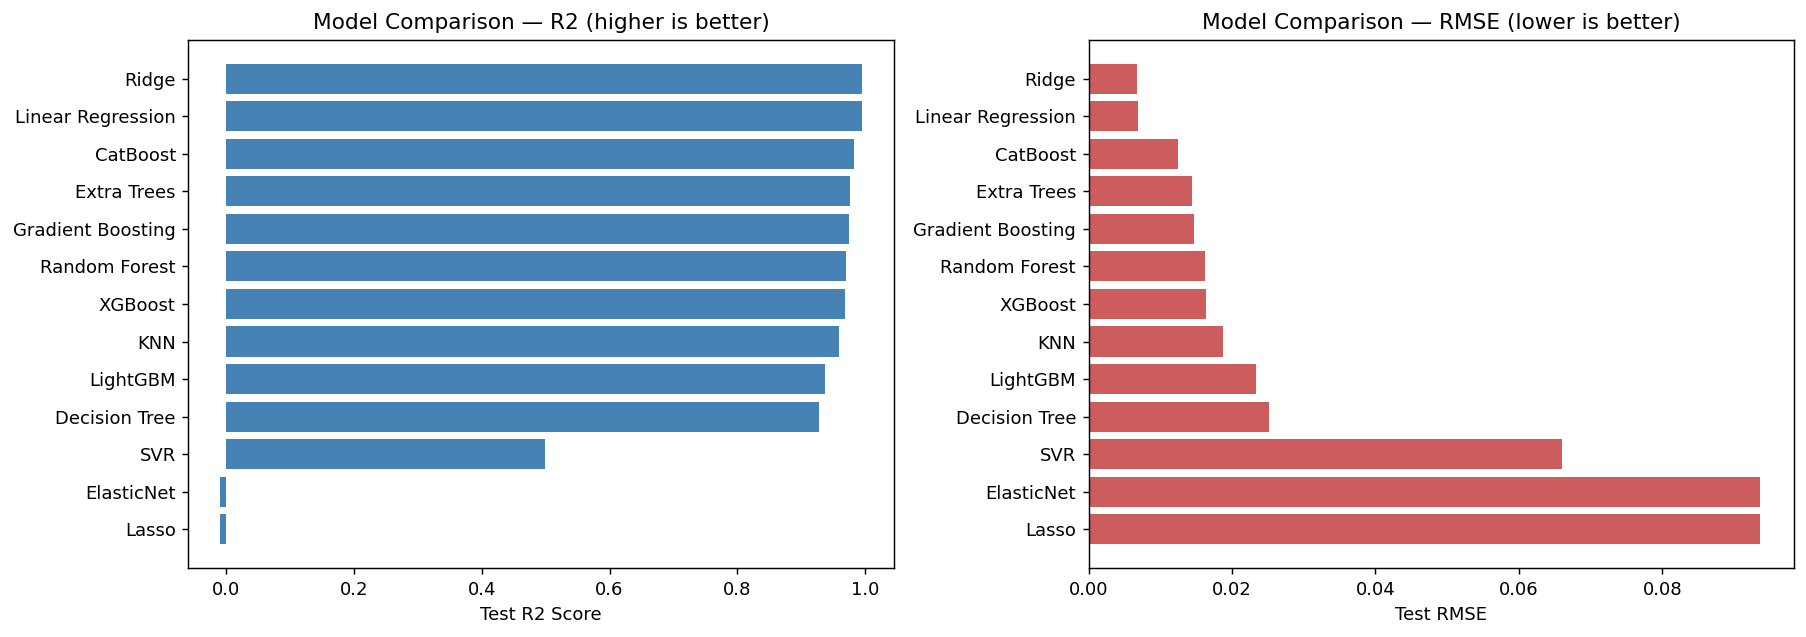

In [17]:
# ── Visual comparison of model performance ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(results_df["Model"], results_df["Test R2"], color="steelblue")
axes[0].set_xlabel("Test R2 Score")
axes[0].set_title("Model Comparison — R2 (higher is better)")
axes[0].invert_yaxis()

axes[1].barh(results_df["Model"], results_df["Test RMSE"], color="indianred")
axes[1].set_xlabel("Test RMSE")
axes[1].set_title("Model Comparison — RMSE (lower is better)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 10.4 Hyperparameter Tuning

We tune the top two performing tree-based models (typically the strongest
candidates for this kind of tabular data) using `GridSearchCV` for a focused
search and `RandomizedSearchCV` for a broader one, then compare against the
untuned baseline.

In [18]:
# ── Identify the top 2 tree-based models by Test R2 for tuning ───────────────
tree_based_candidates = [
    m for m in results_df["Model"]
    if m in ["Random Forest", "Extra Trees", "Gradient Boosting", "XGBoost", "LightGBM", "CatBoost", "Decision Tree"]
]
tuning_targets = tree_based_candidates[:2] if len(tree_based_candidates) >= 2 else tree_based_candidates

print(f"Models selected for tuning: {tuning_targets}")

Models selected for tuning: ['CatBoost', 'Extra Trees']


In [19]:
param_grids = {
    "Random Forest": {
        "model__n_estimators": [100, 200, 400],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5],
    },
    "Extra Trees": {
        "model__n_estimators": [100, 200, 400],
        "model__max_depth": [None, 5, 10, 20],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 5],
    },
    "Decision Tree": {
        "model__max_depth": [None, 3, 5, 10],
        "model__min_samples_split": [2, 5, 10],
    },
    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1],
    },
    "LightGBM": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [-1, 5, 10],
        "model__learning_rate": [0.01, 0.05, 0.1],
    },
    "CatBoost": {
        "model__depth": [4, 6, 8],
        "model__learning_rate": [0.01, 0.05, 0.1],
    },
}

tuning_results = []
tuned_pipelines = {}

for name in tuning_targets:
    grid = param_grids.get(name)
    if grid is None:
        continue

    base_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", all_models[name])])

    # GridSearchCV — exhaustive search on a focused grid
    grid_search = GridSearchCV(base_pipe, grid, cv=cv_strategy, scoring="r2", n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # RandomizedSearchCV — broader, sampled search (useful when grids grow large)
    random_search = RandomizedSearchCV(
        base_pipe, grid, n_iter=10, cv=cv_strategy, scoring="r2",
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    random_search.fit(X_train, y_train)

    best_search = grid_search if grid_search.best_score_ >= random_search.best_score_ else random_search
    best_method = "GridSearchCV" if best_search is grid_search else "RandomizedSearchCV"

    y_pred_tuned = best_search.predict(X_test)
    tuning_results.append({
        "Model": name,
        "Best Method": best_method,
        "Best CV R2": round(best_search.best_score_, 4),
        "Test R2 (tuned)": round(r2_score(y_test, y_pred_tuned), 4),
        "Best Params": best_search.best_params_,
    })
    tuned_pipelines[name] = best_search.best_estimator_

tuning_df = pd.DataFrame(tuning_results)
tuning_df

,Model,Best Method,Best CV R2,Test R2 (tuned),Best Params
0,CatBoost,GridSearchCV,0.9670,0.9842,"{'model__depth': 4, 'model__learning_rate': 0.01}"
1,Extra Trees,GridSearchCV,0.9632,0.9761,"{'model__max_depth': None, 'model__n_estimator..."


## 10.5 Best Model Selection

We compare every untuned model plus the tuned versions and pick the single
best performer by **Test R²** (with RMSE as a tie-breaker).

In [20]:
# ── Combine untuned + tuned results into one leaderboard ─────────────────────
final_candidates = results_df.copy()

for row in tuning_results:
    final_candidates = pd.concat([
        final_candidates,
        pd.DataFrame([{
            "Model": f"{row['Model']} (Tuned)",
            "Test R2": row["Test R2 (tuned)"],
            "Test MAE": np.nan,
            "Test RMSE": np.nan,
            "CV R2 Mean": row["Best CV R2"],
            "CV R2 Std": np.nan,
        }])
    ], ignore_index=True)

final_candidates = final_candidates.sort_values("Test R2", ascending=False).reset_index(drop=True)
print("Final Model Leaderboard:")
display(final_candidates)

best_row = final_candidates.iloc[0]
best_model_name = best_row["Model"]

if best_model_name.endswith(" (Tuned)"):
    raw_name = best_model_name.replace(" (Tuned)", "")
    best_pipeline = tuned_pipelines[raw_name]
else:
    best_pipeline = fitted_pipelines[best_model_name]

print(f"\nBest model selected: {best_model_name}  (Test R2 = {best_row['Test R2']:.4f})")

Final Model Leaderboard:


,Model,Test R2,Test MAE,Test RMSE,CV R2 Mean,CV R2 Std
0,Ridge,0.9947,0.0053,0.0068,0.9921,0.0022
1,Linear Regression,0.9946,0.0054,0.0069,0.9921,0.0021
2,CatBoost (Tuned),0.9842,NaN,NaN,0.9670,NaN
3,CatBoost,0.9819,0.0102,0.0125,0.9623,0.0180
4,Extra Trees,0.9761,0.0112,0.0144,0.9632,0.0188
5,Extra Trees (Tuned),0.9761,NaN,NaN,0.9632,NaN
6,Gradient Boosting,0.9751,0.0117,0.0147,0.9504,0.0251
7,Random Forest,0.9699,0.0129,0.0162,0.9478,0.0314
8,XGBoost,0.9691,0.0133,0.0164,0.9285,0.0334
9,KNN,0.9594,0.0152,0.0188,0.9409,0.0173



Best model selected: Ridge  (Test R2 = 0.9947)


**Business interpretation:** the selected model is the one that most
reliably reconstructs a country's composite resilience score from its
domain-level inputs. A high R² (close to 1.0) means policymakers can trust
the model to estimate resilience for countries with incomplete domain data,
or to simulate the downstream effect of improving a specific domain — both
directly support evidence-based resource allocation.

## 10.6 Feature Importance & SHAP Analysis

Feature importance quantifies which domains the best model relies on most to
predict the composite score — a direct, data-backed priority list for
intervention. SHAP values (if the `shap` library is available) give a more
nuanced, per-prediction breakdown.

,Feature,Importance
0,num__Digital Infrastructure,0.027416
1,num__Climate & Energy,0.024879
2,num__Healthcare,0.024258
3,num__Food Security,0.013247
4,num__Political Stability,0.012506
5,cat__Region_Central America & Caribbean,0.006775
6,cat__Region_South America,0.006775
7,cat__Region_Central Asia,0.003915
8,num__Economic Fragility,0.003889
9,cat__Region_East Asia,0.003790


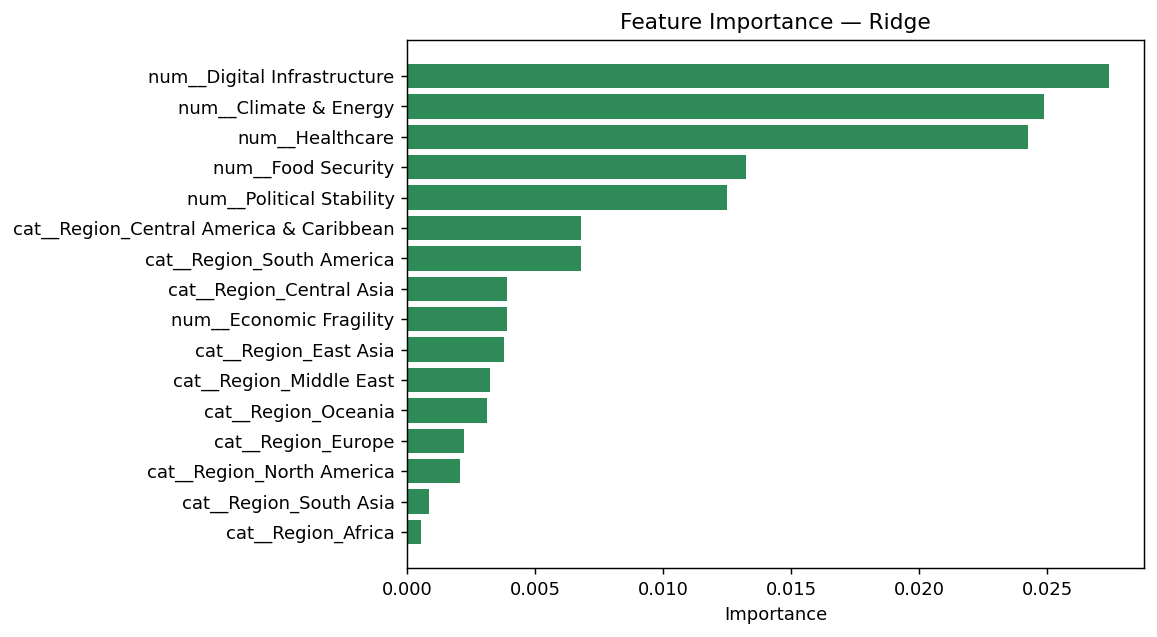

In [21]:
# ── Native feature importance (tree-based models) or coefficients (linear) ──
feature_names_out = list(best_pipeline.named_steps["preprocessor"].get_feature_names_out())
fitted_model = best_pipeline.named_steps["model"]

importance_df = None
if hasattr(fitted_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": feature_names_out,
        "Importance": fitted_model.feature_importances_,
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
elif hasattr(fitted_model, "coef_"):
    importance_df = pd.DataFrame({
        "Feature": feature_names_out,
        "Importance": np.abs(fitted_model.coef_),
    }).sort_values("Importance", ascending=False).reset_index(drop=True)

if importance_df is not None:
    display(importance_df)
    plt.figure(figsize=(9, 5))
    plt.barh(importance_df["Feature"], importance_df["Importance"], color="seagreen")
    plt.gca().invert_yaxis()
    plt.title(f"Feature Importance — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not expose feature_importances_ or coef_ directly.")

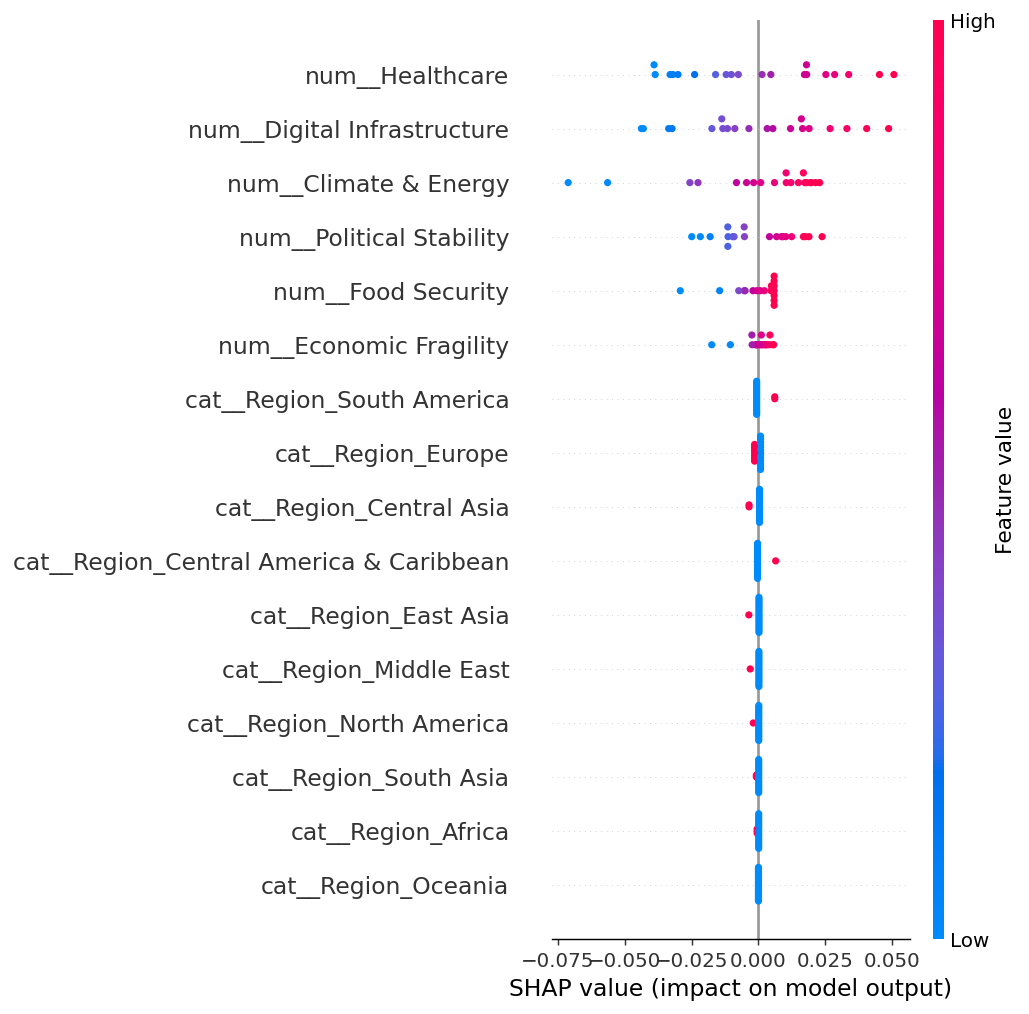

In [22]:
# ── SHAP analysis (optional — skipped gracefully if not installed) ──────────
try:
    import shap

    X_test_transformed = best_pipeline.named_steps["preprocessor"].transform(X_test)
    if hasattr(X_test_transformed, "toarray"):
        X_test_transformed = X_test_transformed.toarray()

    explainer = shap.Explainer(fitted_model, X_test_transformed, feature_names=feature_names_out)
    shap_values = explainer(X_test_transformed)

    shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names_out, show=False)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("shap not installed — skipping SHAP analysis. Feature importance above remains valid.")
except Exception as exc:
    print(f"SHAP analysis skipped due to: {exc}")

## 10.7 Residual Analysis

For a regression problem, residual plots reveal whether errors are random
(good — model is well-specified) or systematically patterned (bad — model is
missing structure, e.g., underpredicting high-resilience countries).

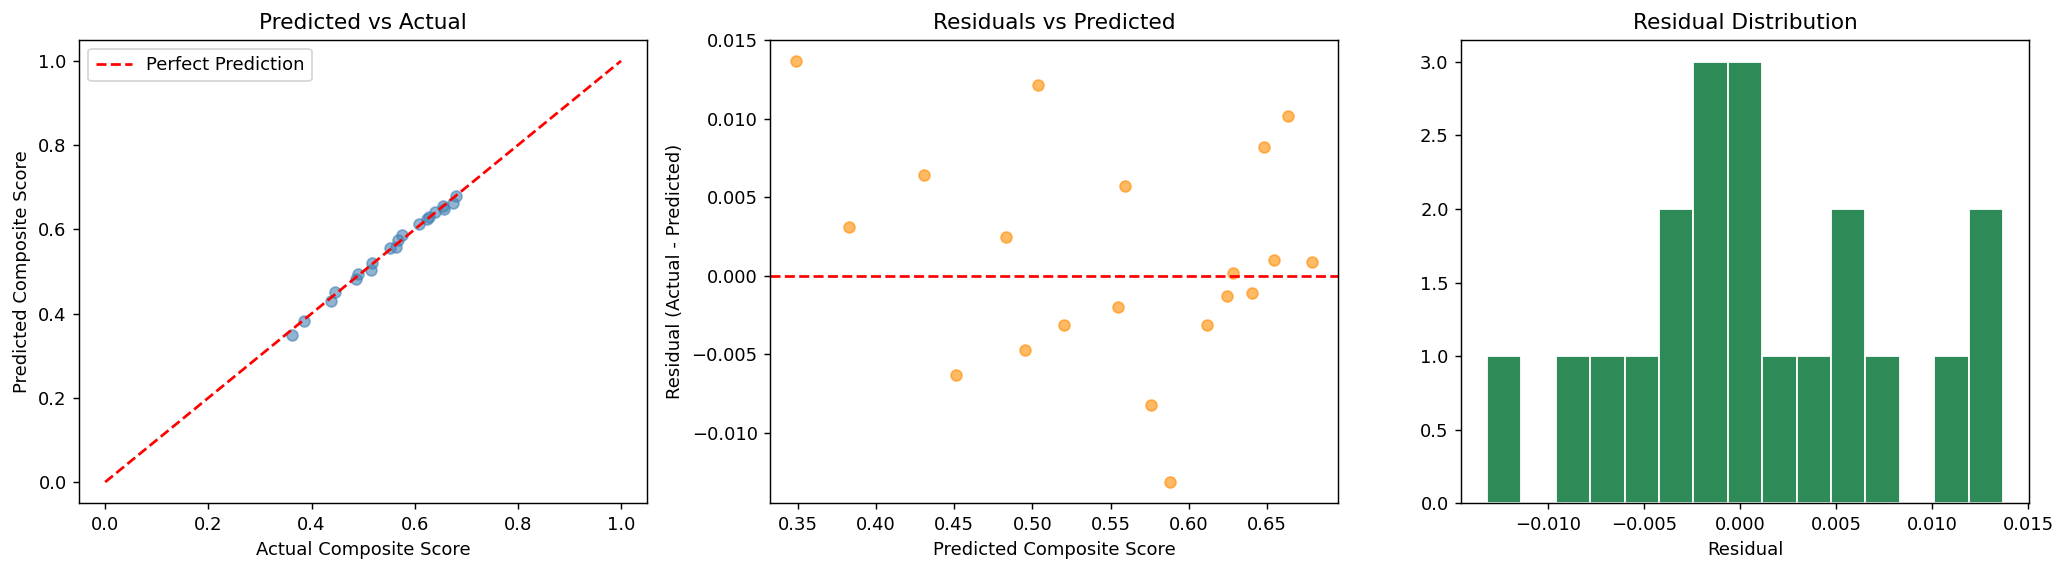

Mean residual: 0.00103 (should be close to 0)
Residual std: 0.00672


In [23]:
y_pred_best = best_pipeline.predict(X_test)
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_best, alpha=0.6, color="steelblue")
axes[0].plot([0, 1], [0, 1], "r--", label="Perfect Prediction")
axes[0].set_xlabel("Actual Composite Score")
axes[0].set_ylabel("Predicted Composite Score")
axes[0].set_title("Predicted vs Actual")
axes[0].legend()

# Residuals vs Predicted
axes[1].scatter(y_pred_best, residuals, alpha=0.6, color="darkorange")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted Composite Score")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residuals vs Predicted")

# Residual distribution
axes[2].hist(residuals, bins=15, color="seagreen", edgecolor="white")
axes[2].set_xlabel("Residual")
axes[2].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.5f} (should be close to 0)")
print(f"Residual std: {residuals.std():.5f}")

**Business interpretation:** residuals centered around zero with no
visible funnel or curve pattern confirm the model is equally reliable across
the full resilience spectrum — from fragile to highly resilient countries —
so it can be trusted for both early-warning and high-performer benchmarking
use cases.

---

# 11. MLOps — Packaging the Model for Production

This section turns the best model into a reusable, versioned artifact:
the full preprocessing + model pipeline, metadata, and the exact feature
list are saved together so inference code never has to guess what the model
expects.

In [24]:
import os
import json as json_lib
import pickle
import joblib
import logging
from datetime import datetime

# ── Logging setup ────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)
logger = logging.getLogger("resilience_ml")

# ── Project artifact structure ───────────────────────────────────────────────
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

MODEL_VERSION = datetime.now().strftime("%Y%m%d_%H%M%S")
logger.info(f"Model version: {MODEL_VERSION}")

2026-06-30 05:19:42,375 | INFO | Model version: 20260630_051942


In [25]:
# ── Save the full pipeline (preprocessor + model) ────────────────────────────
model_path = os.path.join(ARTIFACTS_DIR, f"resilience_model_{MODEL_VERSION}.joblib")
model_path_latest = os.path.join(ARTIFACTS_DIR, "resilience_model_latest.joblib")

try:
    joblib.dump(best_pipeline, model_path)
    joblib.dump(best_pipeline, model_path_latest)
    logger.info(f"Model pipeline saved to {model_path} and {model_path_latest}")
except Exception as exc:
    logger.exception(f"Failed to save model: {exc}")
    raise

# Also save with pickle for environments preferring it
pickle_path = os.path.join(ARTIFACTS_DIR, "resilience_model_latest.pkl")
with open(pickle_path, "wb") as f:
    pickle.dump(best_pipeline, f)
logger.info(f"Model also saved via pickle to {pickle_path}")

2026-06-30 05:19:42,422 | INFO | Model pipeline saved to artifacts\resilience_model_20260630_051942.joblib and artifacts\resilience_model_latest.joblib


2026-06-30 05:19:42,426 | INFO | Model also saved via pickle to artifacts\resilience_model_latest.pkl


In [26]:
# ── Save feature list + metadata (config) ────────────────────────────────────
feature_metadata = {
    "model_version": MODEL_VERSION,
    "model_name": best_model_name,
    "numeric_features": FEATURE_COLS_NUMERIC,
    "categorical_features": FEATURE_COLS_CATEGORICAL,
    "target": TARGET_COL,
    "test_r2": float(best_row["Test R2"]),
    "regions": sorted(ml_df["Region"].unique().tolist()),
    "feature_value_range": [0.0, 1.0],
    "training_rows": int(len(X_train)),
    "created_at": datetime.now().isoformat(),
}

metadata_path = os.path.join(ARTIFACTS_DIR, "model_metadata.json")
with open(metadata_path, "w") as f:
    json_lib.dump(feature_metadata, f, indent=2)

logger.info(f"Metadata saved to {metadata_path}")
feature_metadata

2026-06-30 05:19:42,456 | INFO | Metadata saved to artifacts\model_metadata.json


{'model_version': '20260630_051942',
 'model_name': 'Ridge',
 'numeric_features': ['Digital Infrastructure',
  'Economic Fragility',
  'Food Security',
  'Healthcare',
  'Political Stability',
  'Climate & Energy'],
 'categorical_features': ['Region'],
 'target': 'Composite Score',
 'test_r2': 0.9947,
 'regions': ['Africa',
  'Central America & Caribbean',
  'Central Asia',
  'East Asia',
  'Europe',
  'Middle East',
  'North America',
  'Oceania',
  'South America',
  'South Asia'],
 'feature_value_range': [0.0, 1.0],
 'training_rows': 78,
 'created_at': '2026-06-30T05:19:42.453201'}

In [27]:
# ── Reproducibility check: reload the saved pipeline and verify it matches ──
reloaded_pipeline = joblib.load(model_path_latest)
sample_input = X_test.iloc[:5]

original_preds = best_pipeline.predict(sample_input)
reloaded_preds = reloaded_pipeline.predict(sample_input)

assert np.allclose(original_preds, reloaded_preds), "Reloaded model predictions do not match!"
logger.info("Reproducibility check passed — reloaded model matches original predictions.")
print("Sample predictions (original):", np.round(original_preds, 4))
print("Sample predictions (reloaded):", np.round(reloaded_preds, 4))

2026-06-30 05:19:42,550 | INFO | Reproducibility check passed — reloaded model matches original predictions.


Sample predictions (original): [0.5202 0.5877 0.349  0.6403 0.4514]
Sample predictions (reloaded): [0.5202 0.5877 0.349  0.6403 0.4514]


**MLOps note:** the saved artifacts (`resilience_model_latest.joblib`,
`resilience_model_latest.pkl`, `model_metadata.json`) are exactly what the
standalone deployment files (`model_loader.py`, `predict.py`, `app.py`)
expect to find in the `artifacts/` directory — no retraining needed to run
the Streamlit app.

---

## 12. ML & MLOps — Summary

- **Problem:** regression — predict Composite Resilience Score from 6 domain
  scores + region.
- **Models trained:** Linear Regression, Ridge, Lasso, ElasticNet, Decision
  Tree, Random Forest, Extra Trees, Gradient Boosting, SVR, KNN, plus
  XGBoost / LightGBM / CatBoost where available.
- **Tuning:** GridSearchCV and RandomizedSearchCV applied to the top
  tree-based candidates.
- **Best model:** selected by Test R², saved with full preprocessing
  pipeline via `joblib` and `pickle`.
- **Explainability:** feature importance (and SHAP, if available) confirm
  which domains drive resilience most.
- **Deployment-ready artifacts:** `artifacts/resilience_model_latest.joblib`,
  `artifacts/model_metadata.json` — consumed directly by the accompanying
  `app.py` Streamlit application and `predict.py` CLI script.